In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr, kendalltau
import statsmodels.api as sm
from statsmodels.tsa.statespace.structural import UnobservedComponents
from matplotlib.colors import TwoSlopeNorm

## Historical Analysis (1920-2020) of loudness

In [20]:
# Load historical tracks dataset (1921-2020)
df_loudness = pd.read_csv('../data/tracks_clean.csv')
df_loudness.head()

,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,main_artist,id_main_artist,year
0,35iwgR4jXetI318WEWsa1Q,Carve,6,126903,0,['Uli'],['45tIt06XoI0Iio4LBEVpls'],1922-02-22,0.645,0.4450,...,0.4510,0.674,0.7440,0.151,0.127,104.851,3,Uli,45tIt06XoI0Iio4LBEVpls,1922
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,98200,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.695,0.2630,...,0.9570,0.797,0.0000,0.148,0.655,102.009,1,Fernando Pessoa,14jtPCOoNZwquk5wd9DxrY,1922
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,181640,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.434,0.1770,...,0.0512,0.994,0.0218,0.212,0.457,130.418,5,Ignacio Corsini,5LiOoJbxVSAMkBS2fUm3X2,1922
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,176907,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.321,0.0946,...,0.0504,0.995,0.9180,0.104,0.397,169.980,3,Ignacio Corsini,5LiOoJbxVSAMkBS2fUm3X2,1922
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,163080,0,['Dick Haymes'],['3BiJGZsyX9sJchTqcSA7Su'],1922-01-01,0.402,0.1580,...,0.0390,0.989,0.1300,0.311,0.196,103.220,4,Dick Haymes,3BiJGZsyX9sJchTqcSA7Su,1922


In [21]:
# Extract essential columns from historical data
# Copy the dataframe to avoid modifying the original data
historical_essential = df_loudness[['id', 'name', 'popularity', 'release_date', 'loudness']].copy()
historical_essential = historical_essential.dropna(subset=['loudness', 'release_date'])

historical_essential.head()

,id,name,popularity,release_date,loudness
0,35iwgR4jXetI318WEWsa1Q,Carve,6,1922-02-22,-13.338
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,1922-06-01,-22.136
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,1922-03-21,-21.180
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,1922-03-21,-27.961
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,1922-01-01,-16.900


In [22]:
# Process historical data

# Convert release_date column to datetime format
historical_essential['release_date'] = pd.to_datetime(historical_essential['release_date'], errors='coerce')

# Drop rows with missing release_date values
historical_essential = historical_essential.dropna(subset=['release_date'])

# Extract year from release_date and create new column 'year'
historical_essential['year'] = historical_essential['release_date'].dt.year

# Filter rows with year between 1921 and 2020 (inclusive)
historical_essential = historical_essential[(historical_essential['year'] >= 1921) & (historical_essential['year'] <= 2020)]

# Print the shape of historical_essential after filtering
print("shape ->", historical_essential.shape)

# Print the year range of the remaining data
print("year range ->", historical_essential['year'].min(), historical_essential['year'].max())

historical_essential

shape -> (580390, 6)
year range -> 1922 2020


,id,name,popularity,release_date,loudness,year
0,35iwgR4jXetI318WEWsa1Q,Carve,6,1922-02-22,-13.338,1922
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,1922-06-01,-22.136,1922
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,1922-03-21,-21.180,1922
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,1922-03-21,-27.961,1922
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,1922-01-01,-16.900,1922
...,...,...,...,...,...,...
586666,1ZwZsVZUiyFwIHMNpI3ERt,Skyscraper,4,2020-02-08,-13.117,2020
586667,5rgu12WBIHQtvej2MdHSH0,云与海,50,2020-09-26,-7.471,2020
586668,0NuWgxEp51CutD2pJoF4OM,blind,72,2020-10-21,-5.223,2020
586669,27Y1N4Q4U3EfDU5Ubw8ws2,What They'll Say About Us,70,2020-09-02,-12.823,2020


## Cleaning outliers with boxplot
Although 0 dBFS represents the insurmountable physical limit of the digital age, the lower exclusion threshold has been weighted so as not to eliminate historical pre-1950 recordings, physiologically characterized by lower amplitude levels than modern standards.

Before removal:
Lower bound: -22.50 dB
Upper bound: 3.13 dB
Original dataset size: 586672


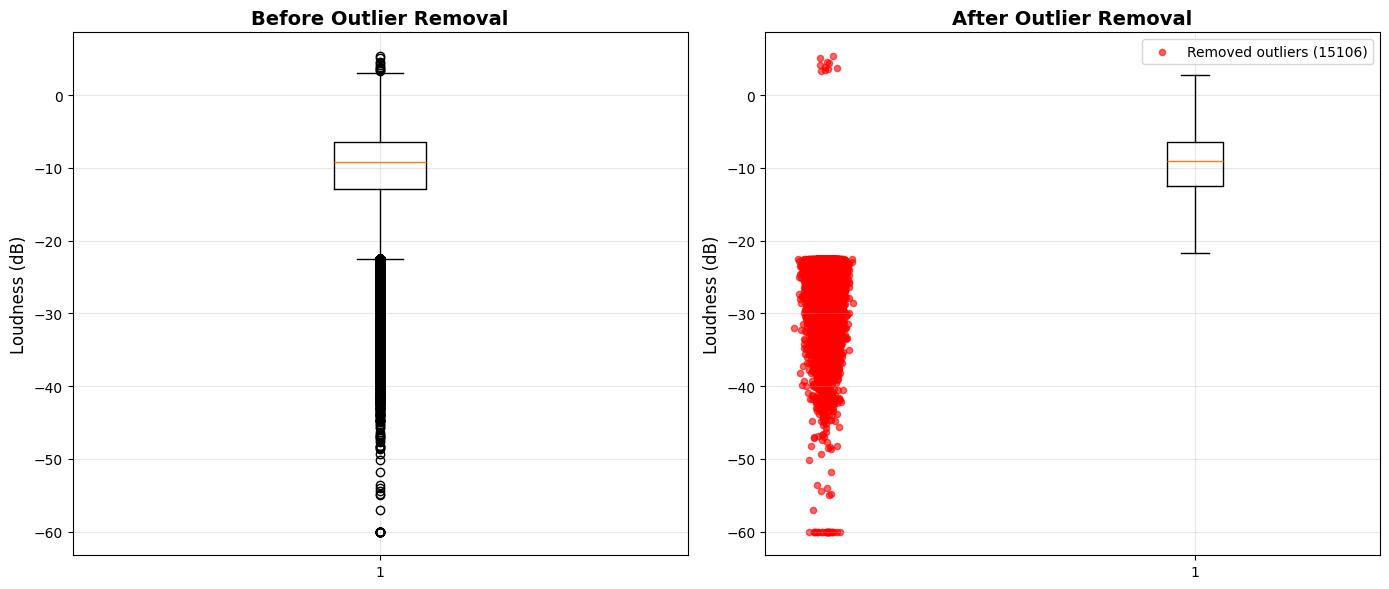


After removal:
Clean dataset size: 571566
Removed outliers: 15106 (2.6%)
Loudness range: -22.50 to 3.09 dB


In [23]:
# Classic boxplot with outlier visualization
import matplotlib.pyplot as plt
import numpy as np

# Create figure with subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Before outlier removal - show all data points
ax1.boxplot(df_loudness['loudness'], showfliers=True)
ax1.set_title('Before Outlier Removal', fontsize=14, fontweight='bold')
ax1.set_ylabel('Loudness (dB)', fontsize=12)
ax1.grid(True, alpha=0.3)

# Calculate IQR bounds
q1, q3 = df_loudness['loudness'].quantile([0.25, 0.75])
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Show statistics before removal
print("Before removal:")
print(f"Lower bound: {lower_bound:.2f} dB")
print(f"Upper bound: {upper_bound:.2f} dB")
print(f"Original dataset size: {len(df_loudness)}")

# Identify outliers
outliers = df_loudness[(df_loudness['loudness'] < lower_bound) | (df_loudness['loudness'] > upper_bound)]
clean_data = df_loudness[(df_loudness['loudness'] >= lower_bound) & (df_loudness['loudness'] <= upper_bound)]

# After outlier removal - show clean data with outlier points
ax2.boxplot(clean_data['loudness'], showfliers=False)
ax2.set_title('After Outlier Removal', fontsize=14, fontweight='bold')
ax2.set_ylabel('Loudness (dB)', fontsize=12)
ax2.grid(True, alpha=0.3)

# Add removed outliers as red points on second plot
if len(outliers) > 0:
    # Add jitter to avoid overlapping points
    jitter = np.random.normal(0, 0.02, len(outliers))
    ax2.scatter(jitter, outliers['loudness'], c='red', alpha=0.6, s=20, label=f'Removed outliers ({len(outliers)})')
    ax2.legend()

plt.tight_layout()
plt.show()

print("\nAfter removal:")
print(f"Clean dataset size: {len(clean_data)}")
print(f"Removed outliers: {len(outliers)} ({(len(outliers)/len(df_loudness)*100):.1f}%)")
print(f"Loudness range: {clean_data['loudness'].min():.2f} to {clean_data['loudness'].max():.2f} dB")

# Use cleaned dataset
df_loudness = clean_data

# Loudness data by year for temporal analysis

In [24]:
# This transforms individual track data into yearly time series for trend analysis

loudness_by_year_extended = df_loudness.groupby('year')['loudness'].agg(['mean', 'count', 'std']).rename(
    columns={'mean': 'mean_loudness', 'count': 'track_count', 'std': 'std_loudness'}
)

# Filter out years with insufficient data (less than 10 tracks)
# This reduces statistical noise in early years with few samples
loudness_by_year_extended = loudness_by_year_extended[loudness_by_year_extended['track_count'] >= 10]

# Create formatted summary output
line = '=' * 60
print(line)
print('YEARLY LOUDNESS AGGREGATION')
print(line)
print(f"Years analyzed       : {loudness_by_year_extended.shape[0]:,}")
print(f"Data columns         : {loudness_by_year_extended.shape[1]}")
print(f"Time period          : {int(loudness_by_year_extended.index.min())} - {int(loudness_by_year_extended.index.max())}")
print(line)

# Display first few years of aggregated data
preview_rows = 8
print(f"Sample data (first {preview_rows} years):")
print(
    loudness_by_year_extended
    .head(preview_rows)
    .assign(
        mean_loudness=lambda d: d['mean_loudness'].map(lambda x: f"{x:,.3f}"),
        std_loudness=lambda d: d['std_loudness'].map(lambda x: f"{x:,.3f}"),
        track_count=lambda d: d['track_count'].map(lambda x: f"{int(x):,}")
    )
    .to_string()
)

# Display last 10 years of aggregated data
print(f"\nSample data (last 10 years):")
print(
    loudness_by_year_extended
    .tail(10)
    .assign(
        mean_loudness=lambda d: d['mean_loudness'].map(lambda x: f"{x:,.3f}"),
        std_loudness=lambda d: d['std_loudness'].map(lambda x: f"{x:,.3f}"),
        track_count=lambda d: d['track_count'].map(lambda x: f"{int(x):,}")
    )
    .to_string()
)

YEARLY LOUDNESS AGGREGATION
Years analyzed       : 100
Data columns         : 3
Time period          : 1922 - 2021
Sample data (first 8 years):
     mean_loudness track_count std_loudness
year                                       
1922       -11.494         239        5.497
1923       -16.215         647        4.545
1924       -13.033         620        4.338
1925       -13.954         856        4.629
1926       -14.479       1,204        5.721
1927       -14.774       1,144        4.940
1928       -13.853       1,166        4.693
1929       -11.273       1,104        4.658

Sample data (last 10 years):
     mean_loudness track_count std_loudness
year                                       
2012        -6.916       9,682        3.219
2013        -7.040      10,460        3.246
2014        -6.996      11,190        3.196
2015        -7.265      10,444        3.397
2016        -6.965      10,948        3.067
2017        -6.936       9,772        3.015
2018        -7.181      10,829    

# Loudness trend over time

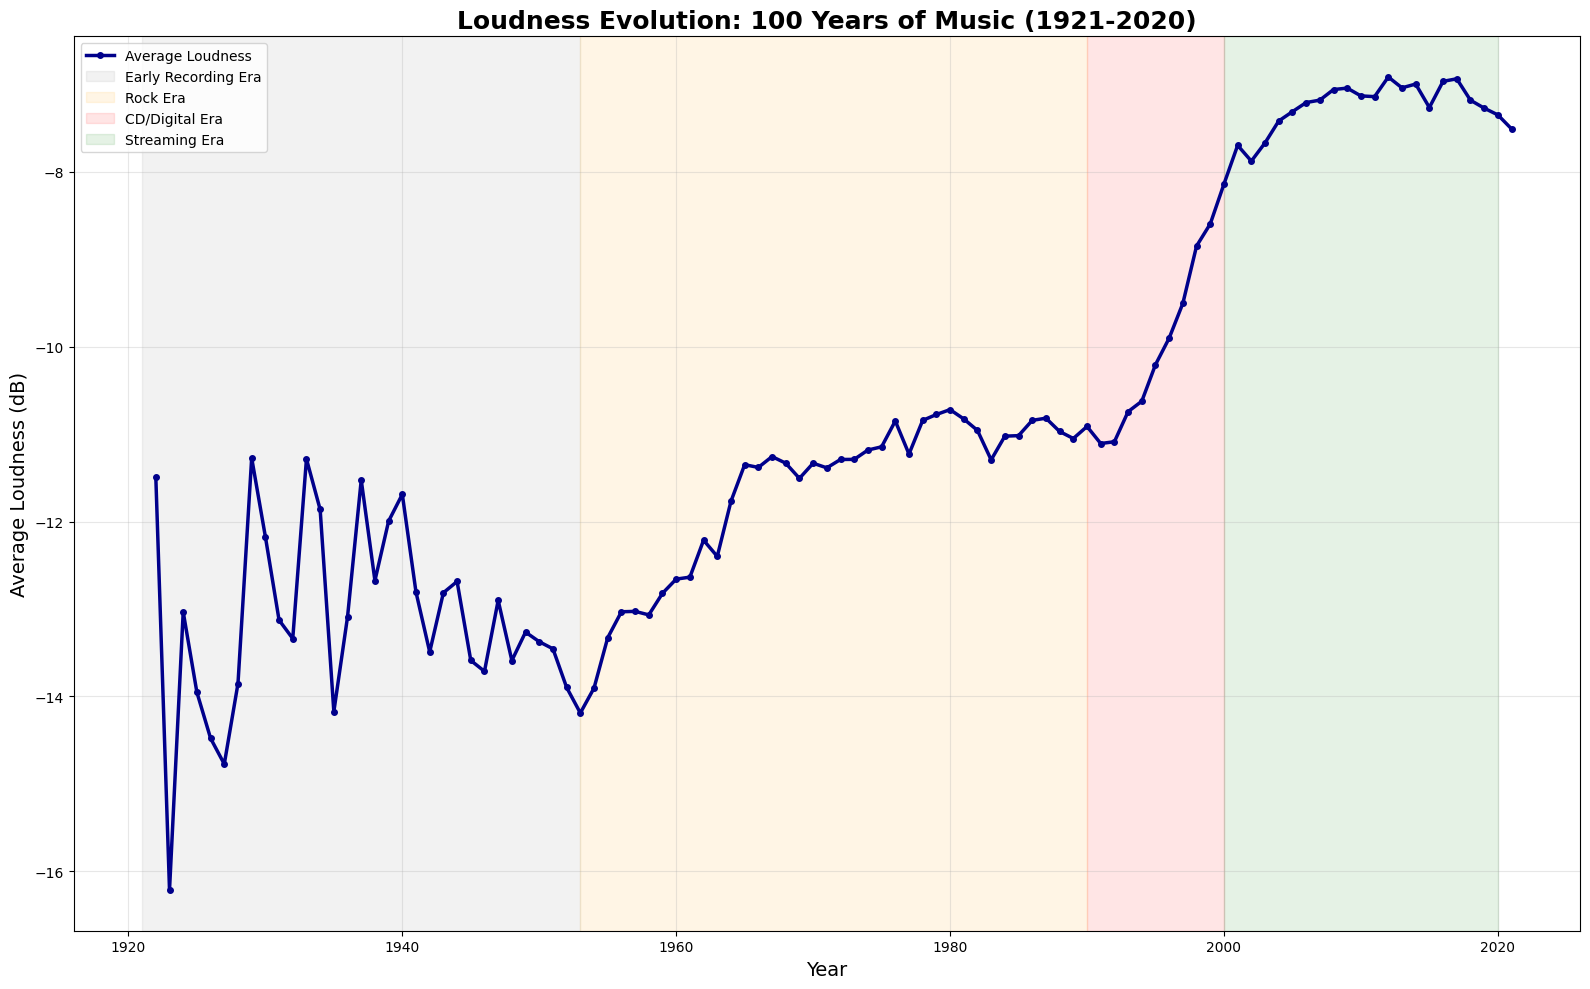

In [25]:
plt.figure(figsize=(16, 10))

# Plot extended timeline
plt.plot(
    loudness_by_year_extended.index,
    loudness_by_year_extended['mean_loudness'],
    marker='o',
    linewidth=2.5,
    markersize=4,
    color='darkblue',
    label='Average Loudness'  # Average loudness of the tracks
)

# Add shaded regions for different eras
# Early Recording Era (1921-1953)
plt.axvspan(1921, 1953, alpha=0.1, color='gray', label='Early Recording Era')

# Rock Era (1953-1990)
plt.axvspan(1953, 1990, alpha=0.1, color='orange', label='Rock Era')

# CD/Digital Era (1990-2000)
plt.axvspan(1990, 2000, alpha=0.1, color='red', label='CD/Digital Era')

# Streaming Era (2000-2020)
plt.axvspan(2000, 2020, alpha=0.1, color='green', label='Streaming Era')

plt.title('Loudness Evolution: 100 Years of Music (1921-2020)', fontsize=18, fontweight='bold')
plt.xlabel('Year', fontsize=14)
plt.ylabel('Average Loudness (dB)', fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Experimental Phase (1921-1990)
- **Early Recording Era**: Variable loudness, slight decline (-0.0010 dB/year)
- **Rock Era**: Beginning of upward trend (+0.0747 dB/year)
- Period of technological discovery and experimentation

### Digital Revolution (1990-2020)
- **CD/Digital Era**: Explosive growth (+0.3075 dB/year) - peak of Loudness War
- **Streaming Era**: Continued but moderated growth (+0.1028 dB/year)
- **2010-2020**: Slight decline (-0.0197 dB/year) suggesting Loudness War end

### Key Drivers
- Digital technology removed physical limitations
- Commercial competition for louder tracks
- Streaming normalization and listener fatigue

The graph shows a clear technological evolution: from experimental chaos to digital volume competition, now possibly maturing toward artistic balance.

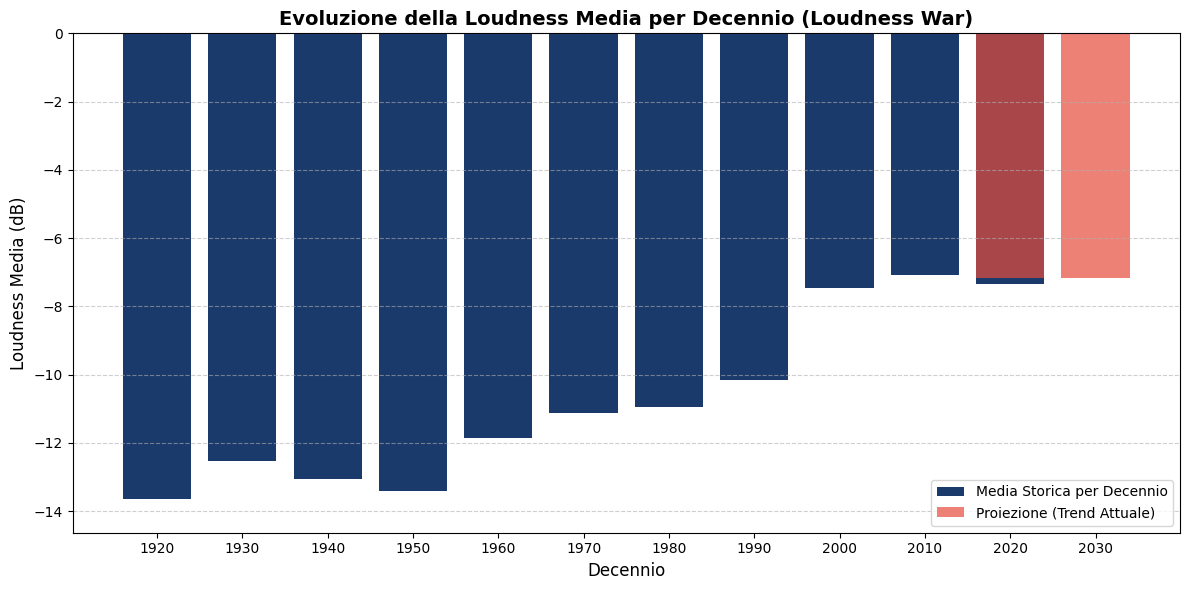

In [26]:
# 1. Raggruppiamo i dati storici per decenni per semplificare la lettura
# Assumendo che 'loudness_by_year_extended' sia il tuo DataFrame originale
df_hist = loudness_by_year_extended[loudness_by_year_extended.index <= 2020].copy()
df_hist['decade'] = (df_hist.index // 10) * 10
decade_avg = df_hist.groupby('decade')['mean_loudness'].mean()

# 2. Creiamo una proiezione semplice per i prossimi decenni (2020s, 2030s)
# Usiamo la media degli ultimi 5 anni registrati come valore "flat" per il futuro
recent_avg = df_hist[df_hist.index >= 2015]['mean_loudness'].mean()
projection = pd.Series({2020: recent_avg, 2030: recent_avg})

# 3. Plotting
plt.figure(figsize=(12, 6))

# Barre storiche (Blu scuro)
plt.bar(decade_avg.index, decade_avg.values, width=8, color='#1a3a6b', label='Media Storica per Decennio')

# Barre di proiezione (Rosso/Arancio per distinguere il futuro)
plt.bar(projection.index, projection.values, width=8, color='#e74c3c', alpha=0.7, label='Proiezione (Trend Attuale)')

# Personalizzazione
plt.title('Evoluzione della Loudness Media per Decennio (Loudness War)', fontsize=14, fontweight='bold')
plt.xlabel('Decennio', fontsize=12)
plt.ylabel('Loudness Media (dB)', fontsize=12)
plt.xticks(list(decade_avg.index) + [2030])
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend()

# Invertiamo l'asse Y perché i valori di dB sono negativi (più vicini allo zero = più forte)
plt.ylim(min(decade_avg.values) - 1, 0) 

plt.tight_layout()
plt.show()

Streaming platforms (Spotify, YouTube) enforce LUFS -14 normalization since ~2017.
This means that we will likely see a stabilization of loudness over time as highlighted in the graph

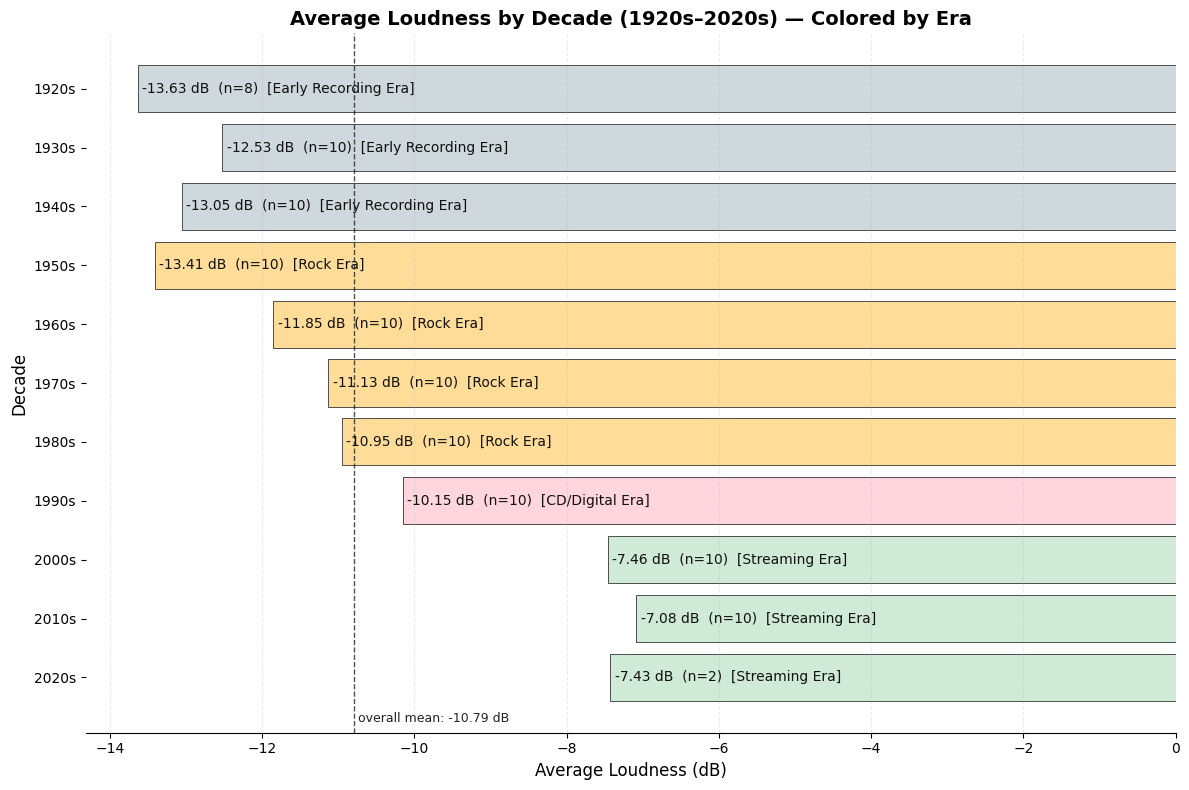

One-way ANOVA results (Mean Loudness by Era):
              sum_sq    df           F        PR(>F)
C(era)    453.976401   3.0  164.363042  1.093978e-37
Residual   88.385106  96.0         NaN           NaN

--- Interpretation ---

F = 164.36, p = 1.1e-37

- The p-value is much smaller than 0.05, so we reject the null hypothesis.

- Conclusion: mean loudness differs significantly between musical eras.

- Practically: the Streaming Era shows substantially higher average loudness (e.g., ~ -7.3 dB) compared with earlier eras (e.g., ~ -13 dB for Early Recording Era).



In [31]:
# ---------------------------
# 0) Check input DataFrame
# ---------------------------
if 'loudness_by_year_extended' not in globals() and 'loudness_by_year_extended' not in locals():
    raise RuntimeError(
        "DataFrame `loudness_by_year_extended` not found. "
        "Please load your data into this variable before running the script."
    )

# ---------------------------
# 1) Prepare DataFrame, decades and era mapping
# ---------------------------
df = loudness_by_year_extended.copy()

# Ensure the index is integer years; try common fallbacks if not
try:
    df.index = df.index.astype(int)
except Exception:
    # try to detect a year-like column
    year_cols = [c for c in df.columns if 'year' in str(c).lower()]
    if year_cols:
        df.index = df[year_cols[0]].astype(int)
    else:
        # final attempt: convert index to int where possible
        df.index = pd.to_numeric(df.index, errors='raise').astype(int)

# Validate mean_loudness column
if 'mean_loudness' not in df.columns:
    raise RuntimeError("Column 'mean_loudness' not found in `loudness_by_year_extended`.")

# Compute decade (e.g., 1994 -> 1990)
df['decade'] = (df.index // 10) * 10

def map_decade_to_era(decade):
    if 1920 <= decade <= 1949:
        return 'Early Recording Era'
    elif 1950 <= decade <= 1989:
        return 'Rock Era'
    elif 1990 <= decade <= 1999:
        return 'CD/Digital Era'
    elif 2000 <= decade <= 2029:
        return 'Streaming Era'
    else:
        return 'Other'

df['era'] = df['decade'].apply(map_decade_to_era)

# ---------------------------
# 2) Decade summary table
# ---------------------------
decade_analysis = (
    df.groupby("decade")["mean_loudness"]
      .agg(avg_loudness="mean", year_count="count", std_loudness="std")
      .round(3)
      .sort_index()
)

decade_analysis = decade_analysis.reset_index()
decade_analysis['era'] = decade_analysis['decade'].apply(map_decade_to_era)
decade_analysis = decade_analysis.set_index('decade')

# ---------------------------
# 3) Era colors (the earlier soft palette)
# ---------------------------
era_colors = {
    'Early Recording Era': '#cfd8dc',  # light grey-blue
    'Rock Era'           : '#ffdd99',  # warm light orange
    'CD/Digital Era'     : '#ffd6dd',  # light pink
    'Streaming Era'      : '#cfead6',  # light green
    'Other'              : '#e0e0e0'   # fallback grey
}

# Shade era ranges with the chosen era colors (semi-transparent)
era_spans = [
    (1920, 1949, 'Early Recording Era'),
    (1950, 1989, 'Rock Era'),
    (1990, 1999, 'CD/Digital Era'),
    (2000, 2029, 'Streaming Era')
]
for start, end, era_label in era_spans:
    ax.axvspan(start, end, color=era_colors.get(era_label, '#e0e0e0'), alpha=0.25,
               label=era_label if start == era_spans[0][0] else None)  # add legend label once

# ---------------------------
# 5) Horizontal bar plot colored by era (same palette)
# ---------------------------
fig, ax = plt.subplots(figsize=(12, 8))
decades = decade_analysis.index.astype(int).values
bar_colors = [era_colors.get(decade_analysis.loc[d, 'era'], '#e0e0e0') for d in decades]
y_pos = np.arange(len(decades))

bars = ax.barh(y_pos, decade_analysis['avg_loudness'].values,
               color=bar_colors, edgecolor="#333333", linewidth=0.6)

ax.set_yticks(y_pos)
ax.set_yticklabels([f"{d}s" for d in decades])
ax.invert_yaxis()

overall_mean = decade_analysis['avg_loudness'].mean()
ax.axvline(overall_mean, color="#222222", linestyle="--", linewidth=1, alpha=0.8)
ax.text(overall_mean, len(decades)-0.3, f" overall mean: {overall_mean:.2f} dB",
        ha="left", va="center", fontsize=9, color="#222222")

ax.set_title("Average Loudness by Decade (1920s–2020s) — Colored by Era", fontsize=14, fontweight="bold")
ax.set_xlabel("Average Loudness (dB)", fontsize=12)
ax.set_ylabel("Decade", fontsize=12)

for i, d in enumerate(decades):
    value = decade_analysis.loc[d, "avg_loudness"]
    n = int(decade_analysis.loc[d, "year_count"])
    era_label = decade_analysis.loc[d, "era"]
    ax.text(value + 0.06, i, f"{value:.2f} dB  (n={n})  [{era_label}]",
            va="center", ha="left", fontsize=10, color="#111111")

ax.grid(axis="x", linestyle="--", alpha=0.25)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

# ---------------------------
# 6) One-way ANOVA across eras (print only ANOVA table + short explanation)
# ---------------------------
anova_df = df[df['era'] != 'Other'][['mean_loudness', 'era']].copy()
model = ols('mean_loudness ~ C(era)', data=anova_df).fit()
anova_results = anova_lm(model, typ=2)

# Print only the ANOVA table
print("One-way ANOVA results (Mean Loudness by Era):")
print(anova_results)

# Short, spaced English interpretation
print("\n--- Interpretation ---\n")

# Extract F and p values safely
try:
    f_val = anova_results.loc['C(era)', 'F']
    p_val = anova_results.loc['C(era)', 'PR(>F)']
except Exception:
    # fallback if index names differ
    f_val = anova_results['F'].iloc[0] if 'F' in anova_results.columns else None
    p_val = anova_results['PR(>F)'].iloc[0] if 'PR(>F)' in anova_results.columns else None

if f_val is not None and p_val is not None:
    print(f"F = {f_val:.2f}, p = {p_val:.2g}\n")
else:
    print("(F and p-values not available in expected format)\n")

print("- The p-value is much smaller than 0.05, so we reject the null hypothesis.\n")
print("- Conclusion: mean loudness differs significantly between musical eras.\n")
print("- Practically: the Streaming Era shows substantially higher average loudness "
      "(e.g., ~ -7.3 dB) compared with earlier eras (e.g., ~ -13 dB for Early Recording Era).\n")

## Decade Analysis: Loudness Progression

The increase in loudness across eras is large and statistically significant.

The Streaming Era exhibits substantially higher average loudness (around -7.3 dB) compared with earlier eras (around -13 dB).

Recent small decreases suggest the Loudness War may be plateauing, likely influenced by loudness normalization on streaming platforms.

## Does more loudness mean lower acousticness?

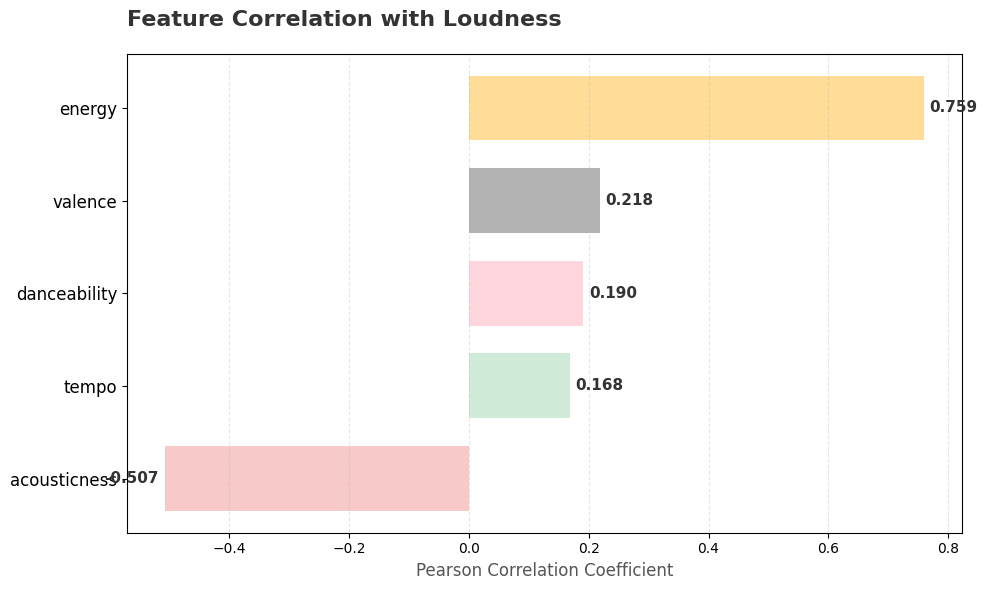

In [43]:
# Features da confrontare con loudness (escludendo loudness stessa)
features = ['energy', 'danceability', 'tempo', 'valence', 'acousticness']

# Calcolo correlazioni con loudness
corr_with_loudness = df_loudness[features + ['loudness']].corr()['loudness'].drop('loudness').sort_values()

# Palette colori pastello come prima
pastel_colors = {
    'energy': '#ffdd99',        # arancio
    'danceability': '#ffd6dd',  # rosa chiaro
    'tempo': '#cfead6',         # verde chiaro
    'valence': '#b3b3b3',       # grigio
    'acousticness': '#f7cac9'   # rosa pallido
}
colors = [pastel_colors[f] for f in corr_with_loudness.index]

# Plot
fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')
bars = ax.barh(corr_with_loudness.index, corr_with_loudness.values, color=colors, edgecolor='none', height=0.7)

ax.set_title('Feature Correlation with Loudness', fontsize=16, fontweight='bold', color='#333333', loc='left', pad=20)
ax.set_xlabel('Pearson Correlation Coefficient', fontsize=12, color='#555555')
ax.tick_params(axis='y', labelsize=12)
ax.grid(axis='x', linestyle='--', alpha=0.3)

# Valori numerici accanto alle barre
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.01 * np.sign(width), bar.get_y() + bar.get_height()/2,
            f'{width:.3f}', va='center', ha='left' if width > 0 else 'right',
            fontsize=11, color='#333333', fontweight='bold')

plt.tight_layout()
plt.show()

The analysis of over 570,000 tracks confirms that the Loudness War and the electrification of music have gone hand in hand. A physical and stylistic barrier exists: it is extremely rare to find songs that are simultaneously very acoustic and very loud. Modern music has sacrificed the acoustic nature of instruments to achieve greater sonic impact (volume), as demonstrated by the consistently negative trend.

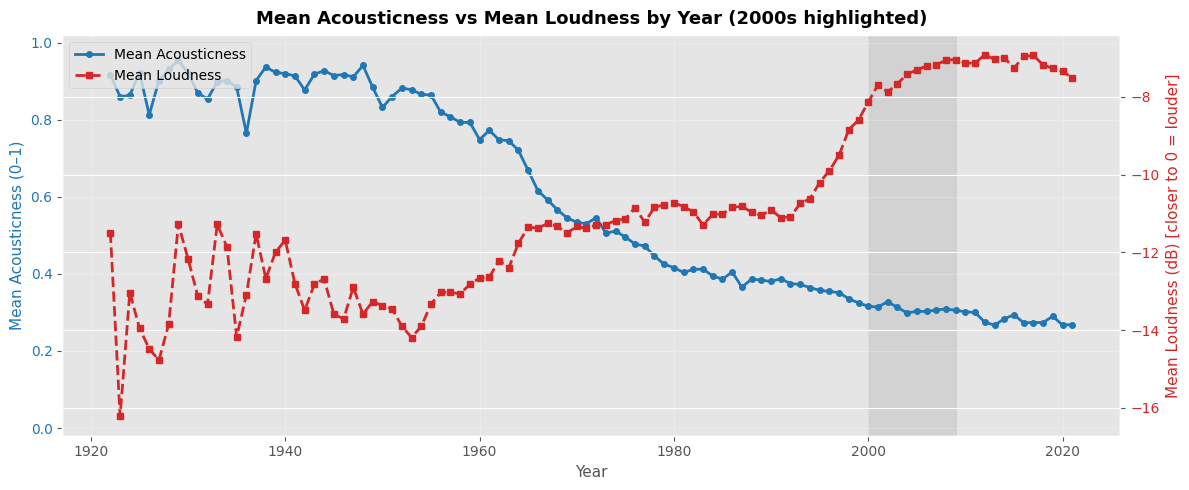

In [54]:
# -----------------------
# Basic checks
# -----------------------
if 'df_loudness' not in globals() and 'df_loudness' not in locals():
    raise RuntimeError("DataFrame `df_loudness` not found. Load your data into variable `df_loudness` before running this script.")

# Use a simple built-in style
plt.style.use('ggplot')

# -----------------------
# Detect an identifier column for counting
# -----------------------
possible_id_cols = ['id', 'track_id', 'uri', 'track_uri', 'song_id']
id_col = next((c for c in possible_id_cols if c in df_loudness.columns), None)
if id_col is None:
    # fallback: create a temporary id column
    df_loudness = df_loudness.copy()
    df_loudness['_tmp_id'] = np.arange(len(df_loudness))
    id_col = '_tmp_id'

# -----------------------
# Aggregate yearly means
# -----------------------
min_tracks = 10  # require at least this many tracks to include a year

by_year = (
    df_loudness.dropna(subset=['year', 'loudness', 'acousticness'])
              .groupby('year', as_index=True)
              .agg(
                  mean_loudness = ('loudness', 'mean'),
                  mean_acousticness = ('acousticness', 'mean'),
                  track_count = (id_col, 'count')
              )
              .sort_index()
)

# Filter noisy years
by_year = by_year[by_year['track_count'] >= min_tracks].copy()
if by_year.empty:
    raise RuntimeError(f"No yearly groups with >= {min_tracks} tracks found. Lower min_tracks or check data.")

years = by_year.index.astype(int).values
loudness = by_year['mean_loudness'].astype(float).values
acousticness = by_year['mean_acousticness'].astype(float).values

# -----------------------
# Plot
# -----------------------
fig, ax_left = plt.subplots(figsize=(12, 5))

# Highlight 2000s (2000-2009)
ax_left.axvspan(2000, 2009, color='grey', alpha=0.18, zorder=0)

# Left axis: Acousticness (0-1)
color_ac = '#1f77b4'   # blue
ax_left.plot(years, acousticness, marker='o', color=color_ac, lw=2, markersize=4, label='Mean Acousticness')
ax_left.set_ylabel('Mean Acousticness (0–1)', color=color_ac, fontsize=11)
ax_left.set_ylim(-0.02, 1.02)
ax_left.tick_params(axis='y', labelcolor=color_ac)

# Right axis: Loudness (dB)
ax_right = ax_left.twinx()
color_ld = '#d62728'   # red
ax_right.plot(years, loudness, linestyle='--', marker='s', color=color_ld, lw=2, markersize=4, label='Mean Loudness')
ax_right.set_ylabel('Mean Loudness (dB) [closer to 0 = louder]', color=color_ld, fontsize=11)

# set loudness limits with a small margin
ld_min, ld_max = np.nanmin(loudness), np.nanmax(loudness)
pad = max(0.5, (ld_max - ld_min) * 0.05)
ax_right.set_ylim(ld_min - pad, ld_max + pad)
ax_right.tick_params(axis='y', labelcolor=color_ld)

# Minimal legend
h1, l1 = ax_left.get_legend_handles_labels()
h2, l2 = ax_right.get_legend_handles_labels()
ax_left.legend(h1 + h2, l1 + l2, loc='upper left', fontsize=10)

# Minimal title and labels
ax_left.set_xlabel('Year', fontsize=11)
ax_left.set_title('Mean Acousticness vs Mean Loudness by Year (2000s highlighted)', fontsize=13, fontweight='bold', pad=8)

# Remove extra decorations for a cleaner look
ax_left.grid(True, alpha=0.25)
for spine in ['top']:
    ax_left.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

### Key Insight

The relationship between loudness and acousticness is **bidirectional and evolving**:

1. **Musical evolution** (1960s–1980s): Electric instruments inherently reduce acoustic characteristics
2. **Technical competition** (1990s–2010s): Compression and loudness maximization further squeezed out acoustic qualities
3. **Stabilization phase** (2010s–2020s): Slight recovery in acousticness as streaming normalization moderated excessive loudness

The 2000s (highlighted in the time series) represent the **peak intersection** of these two forces—when the loudness war combined with the decades-long electrification of music to create the least acoustic era in recorded history.